<a href="https://colab.research.google.com/github/ikhdaaakmalia/Electricity-Consumption-Pattern-Analysis/blob/main/01_DataPreparationEDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**sambungkan dengan google drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import libraries

import sys
!{sys.executable} -m pip install -q seaborn scipy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import os
warnings.filterwarnings('ignore')

In [ ]:
# BASE PATH
BASE_PATH = '/content/drive/MyDrive/SmartHomeAnalysis'

# Path dataset input
DATASET_PATH = os.path.join(BASE_PATH, 'household_power_consumption.txt')

# Path output folder
OUTPUT_PATH = os.path.join(BASE_PATH, 'dupeoutput')

In [ ]:
# Buat folder outputs kalau belum ada
if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)
    print(f"✓ Created output folder: {OUTPUT_PATH}")
else:
    print(f"✓ Output folder exists: {OUTPUT_PATH}")

✓ Created output folder: /content/drive/MyDrive/SmartHomeAnalysis/dupeoutput


In [ ]:
# Check apakah dataset ada
if os.path.exists(DATASET_PATH):
    print(f"✓ Dataset found: {DATASET_PATH}")
    file_size = os.path.getsize(DATASET_PATH) / (1024 * 1024)  # Convert to MB
    print(f"  File size: {file_size:.2f} MB")
else:
    print(f"❌ ERROR: Dataset not found at {DATASET_PATH}")
    raise FileNotFoundError("Dataset not found. Please upload the dataset first.")

print("\n✓ Configuration completed!")
print(f"  Input: {DATASET_PATH}")
print(f"  Output: {OUTPUT_PATH}")

✓ Dataset found: /content/drive/MyDrive/SmartHomeAnalysis/household_power_consumption.txt
  File size: 126.80 MB

✓ Configuration completed!
  Input: /content/drive/MyDrive/SmartHomeAnalysis/household_power_consumption.txt
  Output: /content/drive/MyDrive/SmartHomeAnalysis/dupeoutput


**Menggunakan Sample Mode**

In [ ]:
SAMPLE_MODE = False  # Ubah ke False untuk load full dataset
SAMPLE_SIZE = 50000  # Jumlah rows untuk sample

In [ ]:
if SAMPLE_MODE:
    print(f"⚠ SAMPLE MODE: Loading first {SAMPLE_SIZE:,} rows...")
    print("  (Change SAMPLE_MODE = False to load full dataset)")

    df = pd.read_csv(
        DATASET_PATH,
        sep=';',
        parse_dates={'datetime': ['Date', 'Time']},
        infer_datetime_format=True,
        low_memory=False,
        na_values=['?', ''],
        nrows=SAMPLE_SIZE
    )
else:
    print("⚠ FULL MODE: Loading entire dataset (~2 million rows)...")
    print("  This may take 2-5 minutes...")

    df = pd.read_csv(
        DATASET_PATH,
        sep=';',
        parse_dates={'datetime': ['Date', 'Time']},
        infer_datetime_format=True,
        low_memory=False,
        na_values=['?', '']
    )

print(f"\n✓ Dataset loaded successfully!")
print(f"  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Memory usage: {df.memory_usage().sum() / 1024**2:.2f} MB")
print(f"  Date range: {df['datetime'].min()} to {df['datetime'].max()}")

⚠ FULL MODE: Loading entire dataset (~2 million rows)...
  This may take 2-5 minutes...

✓ Dataset loaded successfully!
  Shape: 2,075,259 rows × 8 columns
  Memory usage: 126.66 MB
  Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00


**data exploration**

In [ ]:
print("\n--- Dataset Info ---")
print(df.info())


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   datetime               datetime64[ns]
 1   Global_active_power    float64       
 2   Global_reactive_power  float64       
 3   Voltage                float64       
 4   Global_intensity       float64       
 5   Sub_metering_1         float64       
 6   Sub_metering_2         float64       
 7   Sub_metering_3         float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 126.7 MB
None


In [ ]:
print("\n--- First 5 Rows ---")
print(df.head())


--- First 5 Rows ---
             datetime  Global_active_power  Global_reactive_power  Voltage  \
0 2006-12-16 17:24:00                4.216                  0.418   234.84   
1 2006-12-16 17:25:00                5.360                  0.436   233.63   
2 2006-12-16 17:26:00                5.374                  0.498   233.29   
3 2006-12-16 17:27:00                5.388                  0.502   233.74   
4 2006-12-16 17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  


In [ ]:
print("\n--- Statistical Summary ---")
print(df.describe())


--- Statistical Summary ---
                            datetime  Global_active_power  \
count                        2075259         2.049280e+06   
mean   2008-12-06 07:12:59.999994112         1.091615e+00   
min              2006-12-16 17:24:00         7.600000e-02   
25%              2007-12-12 00:18:30         3.080000e-01   
50%              2008-12-06 07:13:00         6.020000e-01   
75%              2009-12-01 14:07:30         1.528000e+00   
max              2010-11-26 21:02:00         1.112200e+01   
std                              NaN         1.057294e+00   

       Global_reactive_power       Voltage  Global_intensity  Sub_metering_1  \
count           2.049280e+06  2.049280e+06      2.049280e+06    2.049280e+06   
mean            1.237145e-01  2.408399e+02      4.627759e+00    1.121923e+00   
min             0.000000e+00  2.232000e+02      2.000000e-01    0.000000e+00   
25%             4.800000e-02  2.389900e+02      1.400000e+00    0.000000e+00   
50%             1.000

In [ ]:
print("\n--- Missing Values ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
missing_summary = missing_df[missing_df['Missing Count'] > 0]
if len(missing_summary) > 0:
    print(missing_summary)
else:
    print("No missing values found!")


--- Missing Values ---
                       Missing Count  Percentage
Global_active_power            25979    1.251844
Global_reactive_power          25979    1.251844
Voltage                        25979    1.251844
Global_intensity               25979    1.251844
Sub_metering_1                 25979    1.251844
Sub_metering_2                 25979    1.251844
Sub_metering_3                 25979    1.251844


In [ ]:
print("\n--- Duplicate Rows ---")
dup_count = df.duplicated().sum()
print(f"Total duplicated rows: {dup_count}")


--- Duplicate Rows ---
Total duplicated rows: 0


In [ ]:
print("\n--- Duplicate Timestamps ---")
dup_timestamp = df['datetime'].duplicated().sum()
print(f"Duplicate timestamps: {dup_timestamp}")


--- Duplicate Timestamps ---
Duplicate timestamps: 0


In [ ]:
print("\n--- Invalid or Impossible Values ---")
for col in numeric_columns:
    print(col, "min:", df[col].min(), "| max:", df[col].max())


--- Invalid or Impossible Values ---
Global_active_power min: 0.076 | max: 11.122
Global_reactive_power min: 0.0 | max: 1.39
Voltage min: 223.2 | max: 254.15
Global_intensity min: 0.2 | max: 48.4
Sub_metering_1 min: 0.0 | max: 88.0
Sub_metering_2 min: 0.0 | max: 80.0
Sub_metering_3 min: 0.0 | max: 31.0


In [ ]:
print("\n--- Consistency Check ---")
diff = df['Global_active_power']*1000/60 - (df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3'])
print("Negative differences:", (diff < 0).sum())


--- Consistency Check ---
Negative differences: 1050


**cleaning data**

In [ ]:
# Set datetime sebagai index
df.set_index('datetime', inplace=True)
print("✓ Set datetime as index")

# Handle missing values - Forward Fill (pakai nilai sebelumnya)
missing_before = df.isnull().sum().sum()
print(f"  Before cleaning: {missing_before:,} missing values")

df.fillna(method='ffill', inplace=True)

missing_after = df.isnull().sum().sum()
print(f"  After forward fill: {missing_after:,} missing values")

# Kalau masih ada missing, fill dengan backward fill
if missing_after > 0:
    df.fillna(method='bfill', inplace=True)
    missing_final = df.isnull().sum().sum()
    print(f"  After backward fill: {missing_final:,} missing values")

# Convert ke numeric (kalau ada yang masih string)
numeric_columns = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                   'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("✓ Data cleaning completed!")

✓ Set datetime as index
  Before cleaning: 181,853 missing values
  After forward fill: 0 missing values
✓ Data cleaning completed!


In [ ]:
print("\n--- Missing Values ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
missing_summary = missing_df[missing_df['Missing Count'] > 0]
if len(missing_summary) > 0:
    print(missing_summary)
else:
    print("No missing values found!")


--- Missing Values ---
No missing values found!


**feature enginering**

In [ ]:
# Extract time features
df['hour'] = df.index.hour
df['day'] = df.index.day
df['month'] = df.index.month
df['year'] = df.index.year
df['day_of_week'] = df.index.dayofweek  # 0=Monday, 6=Sunday
df['day_name'] = df.index.day_name()
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

print("✓ Extracted time features: hour, day, month, year, day_of_week, day_name, is_weekend")

# Time category
def categorize_time(hour):
    if 0 <= hour < 6:
        return 'Dawn'
    elif 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'

df['time_category'] = df['hour'].apply(categorize_time)
print("✓ Created time_category feature (Dawn/Morning/Afternoon/Evening)")

# Usage level category
def categorize_usage(power):
    if pd.isna(power):
        return 'Unknown'
    elif power < 1:
        return 'Low'
    elif 1 <= power < 3:
        return 'Medium'
    else:
        return 'High'

df['usage_level'] = df['Global_active_power'].apply(categorize_usage)
print("✓ Created usage_level feature (Low/Medium/High)")

# Calculate total sub-metering
df['Total_sub_metering'] = df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3']
print("✓ Calculated Total_sub_metering")

# Calculate "other" consumption (not captured by sub-meters)
# Formula: (Global_active_power * 1000 / 60) converts kW to Watt-hour per minute
df['Other_consumption'] = (df['Global_active_power'] * 1000 / 60) - df['Total_sub_metering']
df['Other_consumption'] = df['Other_consumption'].clip(lower=0)  # Remove negative values
print("✓ Calculated Other_consumption")

print(f"\n✓ Feature engineering completed!")
print(f"  Total features: {len(df.columns)} columns")

✓ Extracted time features: hour, day, month, year, day_of_week, day_name, is_weekend
✓ Created time_category feature (Dawn/Morning/Afternoon/Evening)
✓ Created usage_level feature (Low/Medium/High)
✓ Calculated Total_sub_metering
✓ Calculated Other_consumption

✓ Feature engineering completed!
  Total features: 18 columns


# **analisa stastistik**

In [ ]:
print(f"Mean Power: {df['Global_active_power'].mean():.2f} kW")
print(f"Max Power: {df['Global_active_power'].max():.2f} kW")
print(f"Min Power: {df['Global_active_power'].min():.2f} kW")
print(f"Std Dev: {df['Global_active_power'].std():.2f} kW")

Mean Power: 1.09 kW
Max Power: 11.12 kW
Min Power: 0.08 kW
Std Dev: 1.05 kW


**hourly pattern**

In [ ]:
print("\n--- Hourly Pattern ---")
# Calculate the hourly average power consumption
hourly_avg = df.groupby('hour')['Global_active_power'].mean()

print(f"Peak Hour: {hourly_avg.idxmax()}:00 ({hourly_avg.max():.2f} kW)")
print(f"Lowest Hour: {hourly_avg.idxmin()}:00 ({hourly_avg.min():.2f} kW)")


--- Hourly Pattern ---
Peak Hour: 20:00 (1.89 kW)
Lowest Hour: 4:00 (0.45 kW)


In [ ]:
# Weekday vs Weekend
weekday_avg = df[df['is_weekend']==0]['Global_active_power'].mean()
weekend_avg = df[df['is_weekend']==1]['Global_active_power'].mean()
pct_diff = ((weekend_avg - weekday_avg) / weekday_avg) * 100

print("\n--- Weekday vs Weekend ---")
print(f"Weekday: {weekday_avg:.2f} kW")
print(f"Weekend: {weekend_avg:.2f} kW")
print(f"Difference: {abs(pct_diff):.1f}% {'higher' if pct_diff > 0 else 'lower'} on weekend")


--- Weekday vs Weekend ---
Weekday: 1.03 kW
Weekend: 1.22 kW
Difference: 17.7% higher on weekend


In [ ]:
# Sub-metering
total_sub = df['Total_sub_metering'].sum()
sub1_pct = (df['Sub_metering_1'].sum()/total_sub)*100
sub2_pct = (df['Sub_metering_2'].sum()/total_sub)*100
sub3_pct = (df['Sub_metering_3'].sum()/total_sub)*100

print("\n--- Sub-metering Breakdown ---")
print(f"Kitchen: {sub1_pct:.1f}%")
print(f"Laundry: {sub2_pct:.1f}%")
print(f"Climate: {sub3_pct:.1f}%")


--- Sub-metering Breakdown ---
Kitchen: 12.6%
Laundry: 14.6%
Climate: 72.8%


# **Visualisasi Utama**

✓ Saved: /content/drive/MyDrive/SmartHomeAnalysis/dupeoutput/overview.png


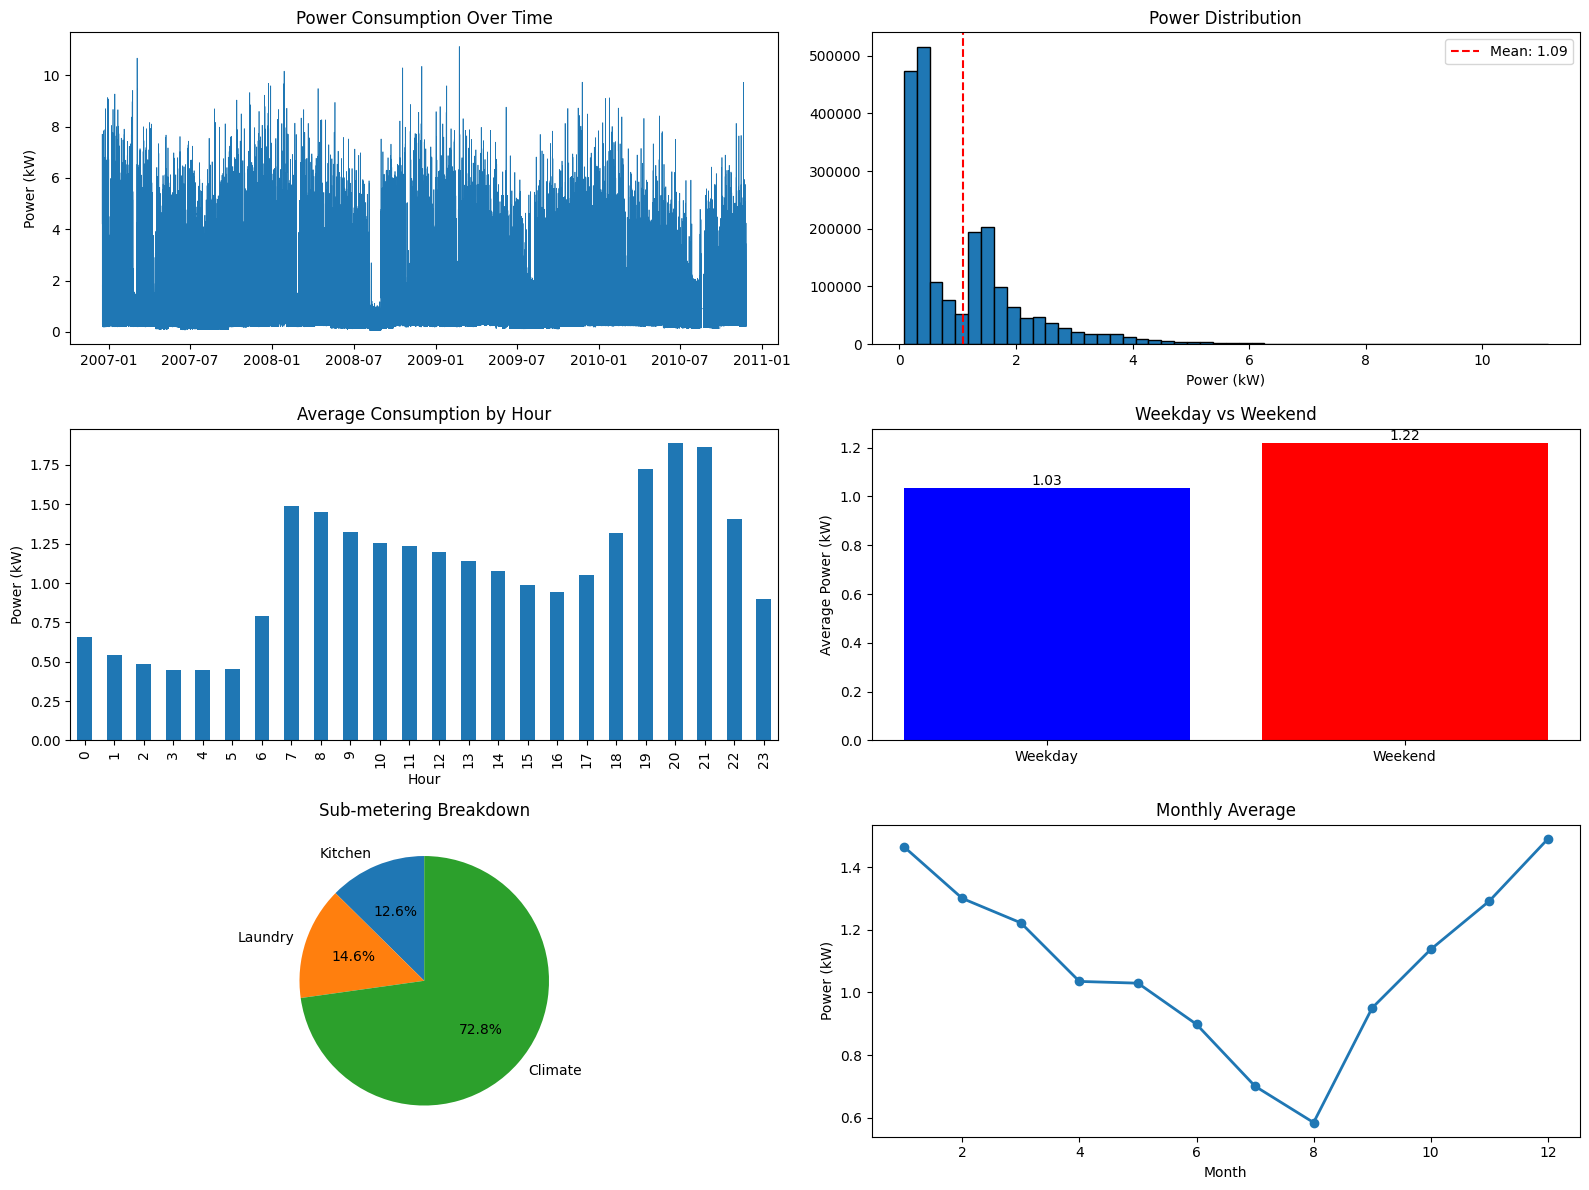

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# 1. Time Series
axes[0,0].plot(df.index, df['Global_active_power'], linewidth=0.5)
axes[0,0].set_title('Power Consumption Over Time')
axes[0,0].set_ylabel('Power (kW)')

# 2. Distribution
axes[0,1].hist(df['Global_active_power'].dropna(), bins=50, edgecolor='black')
axes[0,1].set_title('Power Distribution')
axes[0,1].set_xlabel('Power (kW)')
axes[0,1].axvline(df['Global_active_power'].mean(), color='red', linestyle='--',
                  label=f"Mean: {df['Global_active_power'].mean():.2f}")
axes[0,1].legend()

# 3. Hourly Pattern
hourly_avg.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Average Consumption by Hour')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Power (kW)')

# 4. Weekday vs Weekend
weekend_data = [weekday_avg, weekend_avg]
axes[1,1].bar(['Weekday', 'Weekend'], weekend_data, color=['blue', 'red'])
axes[1,1].set_title('Weekday vs Weekend')
axes[1,1].set_ylabel('Average Power (kW)')
for i, v in enumerate(weekend_data):
    axes[1,1].text(i, v, f'{v:.2f}', ha='center', va='bottom')

# 5. Sub-metering Pie
sub_data = [sub1_pct, sub2_pct, sub3_pct]
axes[2,0].pie(sub_data, labels=['Kitchen', 'Laundry', 'Climate'],
              autopct='%1.1f%%', startangle=90)
axes[2,0].set_title('Sub-metering Breakdown')

# 6. Monthly Trend
monthly_avg = df.groupby('month')['Global_active_power'].mean()
axes[2,1].plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2)
axes[2,1].set_title('Monthly Average')
axes[2,1].set_xlabel('Month')
axes[2,1].set_ylabel('Power (kW)')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'overview.png'), dpi=300, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_PATH}/overview.png")
plt.show()

# **HEATMAP **

✓ Saved: /content/drive/MyDrive/SmartHomeAnalysis/dupeoutput/heatmap.png


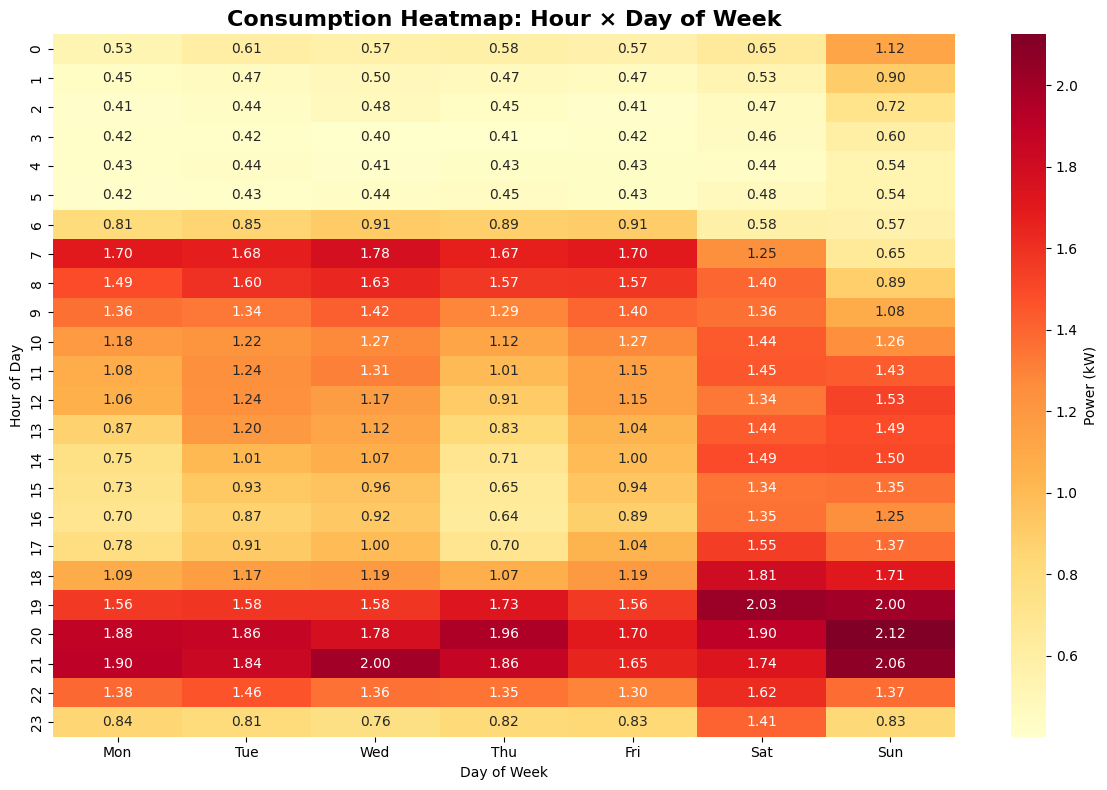

In [ ]:
# Create pivot table
pivot = df.pivot_table(
    values='Global_active_power',
    index='hour',
    columns='day_of_week',
    aggfunc='mean'
)

# Rename columns
day_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
pivot.columns = [day_map[col] for col in pivot.columns]

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.2f', cbar_kws={'label': 'Power (kW)'})
plt.title('Consumption Heatmap: Hour × Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'heatmap.png'), dpi=300, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_PATH}/heatmap.png")
plt.show()

In [ ]:
# Save cleaned data
csv_path = os.path.join(OUTPUT_PATH, 'cleaned_data.csv')
df.to_csv(csv_path)
print(f"✓ Saved CSV: {csv_path}")

# Save summary
summary_path = os.path.join(OUTPUT_PATH, 'summary.txt')
with open(summary_path, 'w') as f:
    f.write("ANALYSIS SUMMARY\n")
    f.write("="*50 + "\n\n")
    f.write(f"Total Records: {len(df):,}\n")
    f.write(f"Date Range: {df.index.min()} to {df.index.max()}\n\n")
    f.write(f"Mean Power: {df['Global_active_power'].mean():.2f} kW\n")
    f.write(f"Peak Hour: {hourly_avg.idxmax()}:00\n")
    f.write(f"Weekday Avg: {weekday_avg:.2f} kW\n")
    f.write(f"Weekend Avg: {weekend_avg:.2f} kW\n\n")
    f.write(f"Kitchen: {sub1_pct:.1f}%\n")
    f.write(f"Laundry: {sub2_pct:.1f}%\n")
    f.write(f"Climate: {sub3_pct:.1f}%\n")

print(f"✓ Saved summary: {summary_path}")

# Save statistics
stats_data = {
    'Metric': ['Total Records', 'Mean Power', 'Peak Hour', 'Weekday Avg', 'Weekend Avg',
               'Kitchen %', 'Laundry %', 'Climate %'],
    'Value': [len(df), f"{df['Global_active_power'].mean():.2f}",
              f"{hourly_avg.idxmax()}:00", f"{weekday_avg:.2f}", f"{weekend_avg:.2f}",
              f"{sub1_pct:.1f}", f"{sub2_pct:.1f}", f"{sub3_pct:.1f}"]
}
stats_df = pd.DataFrame(stats_data)
stats_path = os.path.join(OUTPUT_PATH, 'statistics.csv')
stats_df.to_csv(stats_path, index=False)
print(f"✓ Saved statistics: {stats_path}")

print("\n" + "="*60)
print("✅ ANALYSIS COMPLETED!")
print("="*60)
print(f"\nOutput folder: {OUTPUT_PATH}")
print("\nFiles created:")
print("1. overview.png - 6 visualization charts")
print("2. heatmap.png - Hour × Day heatmap")
print("3. cleaned_data.csv - Processed dataset")
print("4. summary.txt - Text summary")
print("5. statistics.csv - Key statistics table")

✓ Saved CSV: /content/drive/MyDrive/SmartHomeAnalysis/dupeoutput/cleaned_data.csv
✓ Saved summary: /content/drive/MyDrive/SmartHomeAnalysis/dupeoutput/summary.txt
✓ Saved statistics: /content/drive/MyDrive/SmartHomeAnalysis/dupeoutput/statistics.csv

✅ ANALYSIS COMPLETED!

Output folder: /content/drive/MyDrive/SmartHomeAnalysis/dupeoutput

Files created:
1. overview.png - 6 visualization charts
2. heatmap.png - Hour × Day heatmap
3. cleaned_data.csv - Processed dataset
4. summary.txt - Text summary
5. statistics.csv - Key statistics table
